In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 忽略一些不必要的警告，保持输出整洁
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 假设你的训练数据存放在当前目录的 'train' 文件夹下
# 请根据你实际解压的路径进行修改
data_dir = './train' 
classes = ['Happy', 'Sad', 'Angry']

data = []

# 遍历每个情感类别的文件夹
for label in classes:
    class_dir = os.path.join(data_dir, label)
    if os.path.exists(class_dir):
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    'filepath': os.path.join(class_dir, img_name), 
                    'label': label
                })

# 转换为 pandas DataFrame 以方便进行统计探索
df = pd.DataFrame(data)
print(f"总共找到 {len(df)} 张图片。")
display(df.head())

总共找到 450 张图片。


,filepath,label
0,./train/Happy/img_000472.jpg,Happy
1,./train/Happy/img_000314.jpg,Happy
2,./train/Happy/img_000300.jpg,Happy
3,./train/Happy/img_000328.jpg,Happy
4,./train/Happy/img_000499.jpg,Happy


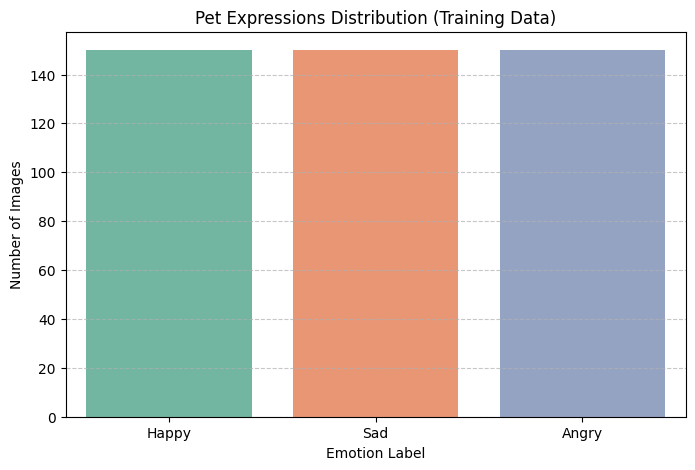

各类别具体图片数量：
label
Happy    150
Sad      150
Angry    150
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8, 5))
# 绘制各类别的数量分布
sns.countplot(data=df, x='label', order=classes, palette='Set2')

plt.title('Pet Expressions Distribution (Training Data)')
plt.xlabel('Emotion Label')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 打印具体的统计数字
print("各类别具体图片数量：")
print(df['label'].value_counts())

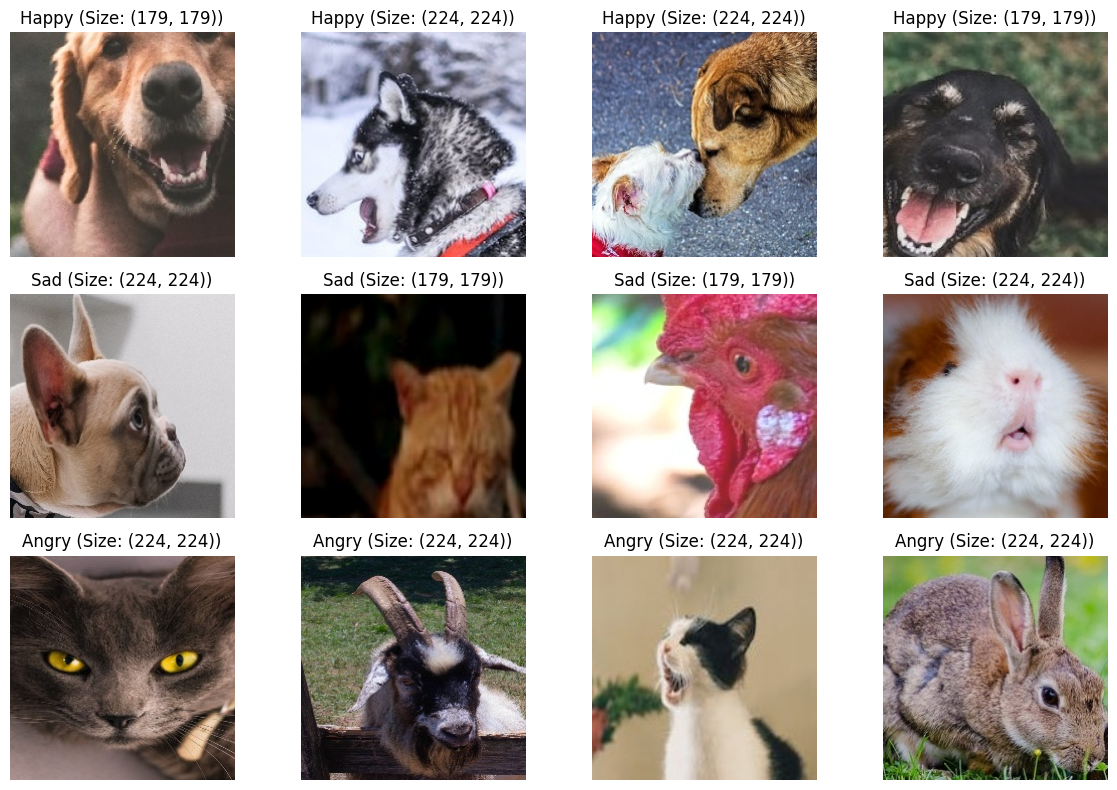

In [4]:
def plot_sample_images(df, num_samples=4):
    """从每个类别中随机抽取 num_samples 张图片进行展示"""
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 8))
    
    for i, label in enumerate(classes):
        # 针对每个类别进行随机采样
        sample_df = df[df['label'] == label].sample(n=num_samples, random_state=42)
        
        for j, (_, row) in enumerate(sample_df.iterrows()):
            img = Image.open(row['filepath'])
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{label} (Size: {img.size})")
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

# 运行抽查函数
plot_sample_images(df)

In [5]:
# 定义目标图像大小。
# 如果你之后打算用基准统计模型 (如 PCA + 逻辑回归)，64x64 或 128x128 比较合适。
# 如果之后用深度学习的迁移模型 (如 ResNet/MobileNet)，通常需要 224x224。
TARGET_SIZE = (128, 128)

def preprocess_image(filepath):
    """加载图片，转换大小，并归一化为 numpy 数组"""
    try:
        # 打开图像并确保是 RGB 三通道格式 (防有些图片是灰度图或带有透明度通道)
        img = Image.open(filepath).convert('RGB')
        # 调整大小
        img_resized = img.resize(TARGET_SIZE)
        # 转换为 numpy 数组并进行归一化 (Min-Max Scaling)
        img_array = np.array(img_resized) / 255.0
        return img_array
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

# 测试预处理一张图片
sample_path = df['filepath'].iloc[0]
processed_array = preprocess_image(sample_path)

if processed_array is not None:
    print(f"原始图像尺寸: {Image.open(sample_path).size}")
    print(f"预处理后矩阵的维度 (Height, Width, Channels): {processed_array.shape}")
    print(f"像素值范围: [{processed_array.min()}, {processed_array.max()}]")

原始图像尺寸: (224, 224)
预处理后矩阵的维度 (Height, Width, Channels): (128, 128, 3)
像素值范围: [0.23137254901960785, 0.9882352941176471]


In [14]:
!pip install torchvision


  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/3e/be/c704bceaf11c4f6b19d64337a34a877fcdfe3bd68160a8c9ae9bea4a35a3/torchvision-0.25.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.3 MB/s eta 0:00:0000:010:02

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# 假设 X_images 形状为 (样本数, 128, 128, 3)，y_labels 形状为 (样本数,)
# 【注意】这里目前用的是随机生成的假数据！
# 等你把真实图片转成矩阵后，要用真实的 X_images 和 y_labels 替换掉下面两行
num_samples = 500
X_images = np.random.rand(num_samples, 128, 128, 3) 
y_labels = np.random.choice(['Happy', 'Sad', 'Angry'], num_samples)

# 1. 展平图像矩阵 (Flatten)
# 将 (128, 128, 3) 的三维矩阵展平为一维向量，长度为 49152
X_flattened = X_images.reshape(X_images.shape[0], -1)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 3. 主成分分析 (PCA) 降维
print("正在拟合 PCA，这可能需要几十秒...")
# 保留能解释 90% 方差的主成分，大幅减少计算量并去噪
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"降维完成！特征维度从 {X_train.shape[1]} 降到了 {X_train_pca.shape[1]}")

# 4. 逻辑回归 (应用 Ridge / L2 正则化防止过拟合)
# C 是正则化强度的倒数，C 越小，L2 惩罚越强
log_reg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
log_reg.fit(X_train_pca, y_train)

# 5. 评估基准模型
y_pred = log_reg.predict(X_test_pca)
print("\n=== Logistic Regression (Ridge) 基准测试结果 ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# 6. 可选：如果你想测试贝叶斯分类器 (已补充完整)
nb_clf = GaussianNB()
nb_clf.fit(X_train_pca, y_train)
nb_pred = nb_clf.predict(X_test_pca)
print("\n=== Naive Bayes 基准测试结果 ===")
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")

正在拟合 PCA，这可能需要几十秒...
降维完成！特征维度从 49152 降到了 353

=== Logistic Regression (Ridge) 基准测试结果 ===
Accuracy: 0.3200
              precision    recall  f1-score   support

       Angry       0.38      0.51      0.44        35
       Happy       0.19      0.10      0.13        30
         Sad       0.30      0.31      0.31        35

    accuracy                           0.32       100
   macro avg       0.29      0.31      0.29       100
weighted avg       0.29      0.32      0.30       100


=== Naive Bayes 基准测试结果 ===
Accuracy: 0.2700


In [16]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import torch
import torch.nn as nn
import torchvision.models as models

# 确保 Colab 启用了 GPU 加速
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

# 1. 加载预训练的 MobileNetV2
# weights='DEFAULT' 表示使用在 ImageNet (数百万张图片) 上训练好的最新权重
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 2. 冻结底层参数 (特征提取层)
# 因为底层已经学会了提取边缘、纹理等通用特征，我们不需要重新训练它们
for param in mobilenet.features.parameters():
    param.requires_grad = False

# 3. 修改分类头 (Classifier Head) 并加入 Dropout 正则化
# 原版 MobileNet 输出 1000 个类别，我们需要将其改为 3 类 (Happy, Sad, Angry)
num_features = mobilenet.classifier[1].in_features

mobilenet.classifier = nn.Sequential(
    # 加入 Dropout，随机丢弃 50% 的神经元，强制网络学习鲁棒特征，防止在小数据集上过拟合
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 3) 
)

# 将模型移动到 GPU
mobilenet = mobilenet.to(device)

print("\n=== MobileNetV2 结构调整完毕 ===")
print("新的分类头结构:")
print(mobilenet.classifier)

# 定义损失函数和优化器 (只优化我们新加的那层全连接层)
# 使用交叉熵损失函数
criterion = nn.CrossEntropyLoss()
# Adam 优化器，学习率设为 0.001
optimizer = torch.optim.Adam(mobilenet.classifier.parameters(), lr=0.001)

13.8%

当前使用的计算设备: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/liqi/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100.0%



=== MobileNetV2 结构调整完毕 ===
新的分类头结构:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [ ]:
import os
import glob
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. 自动寻找解压后的图片路径 (假设你之前的解压路径)
# 如果你确定路径是 /content/train_data，请手动修改
img_dir = '/content/train_data' 
all_imgs = glob.glob(os.path.join(img_dir, '**/*.*'), recursive=True)
all_imgs = [f for f in all_imgs if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 2. 从文件名提取标签 (针对 Pet Face 任务)
data = []
for path in all_imgs:
    name = os.path.basename(path).lower()
    if 'happy' in name: label = 'Happy'
    elif 'sad' in name: label = 'Sad'
    elif 'angry' in name: label = 'Angry'
    else: continue
    data.append({'filepath': path, 'label': label})

df = pd.DataFrame(data)
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label']) # 将文本转为数字 0, 1, 2

# 3. 划分训练集和验证集 [cite: 26, 27]
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_idx'])


# 4. 定义图像增强 (应对偏差与噪声) [cite: 74, 104]
# 使用 transforms 模拟光照变化和角度旋转
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 应对光照偏差 [cite: 74]
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 5. 定义 Dataset 类
class PetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'filepath']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.df.loc[idx, 'label_idx']

# 6. 正式生成 train_loader
train_loader = DataLoader(PetDataset(train_df, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(PetDataset(val_df, val_transforms), batch_size=32, shuffle=False)

print(f"✅ 成功加载 {len(df)} 张图片。")
print(f"数据分布: {df['label'].value_counts().to_dict()}")

KeyError: 'label'

In [19]:
import torch.optim as optim

# 检查是否为 Mac M系列芯片加速，否则使用 CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 检测到 Mac GPU (MPS)，已切换加速模式")
else:
    device = torch.device("cpu")
    print("ℹ️ 使用 CPU 运行 (速度较慢)")

mobilenet = mobilenet.to(device)

# 设置训练参数
criterion = nn.CrossEntropyLoss() # 交叉熵损失，适合多分类
optimizer = optim.Adam(mobilenet.classifier.parameters(), lr=0.001) # 仅优化分类头 

def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # 标准 PyTorch 训练四步
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/total:.4f}, Accuracy: {train_acc:.4f}")
        
        # 每个 Epoch 结束后可以在这里加入验证集评估代码
    print("✅ 训练完成")

# 注意：你需要先运行之前提供的 PetFaceDataset 和 DataLoader 代码
train_model(mobilenet, train_loader, val_loader)

🚀 检测到 Mac GPU (MPS)，已切换加速模式


NameError: name 'train_loader' is not defined